In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [95]:
df=pd.read_csv("/Users/meghaprajapati/Desktop/auto-mpg.csv")

In [97]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


## Auto MPG Dataset: Column Explanations

**mpg** Miles per gallon (MPG), a measure of fuel efficiency for the car. Higher values indicate better fuel economy.

**cylinders** The number of cylinders in the engine, typically 4, 6, or 8. More cylinders generally indicate a more powerful engine.

**displacement** Engine displacement in cubic inches. It refers to the total volume of air/fuel mixture an engine can draw in during one cycle.

**horsepower** The engine’s power output, measured in horsepower. Higher values indicate more powerful engines.

**weight** The vehicle’s weight in pounds. Heavier vehicles generally have lower fuel efficiency.

**acceleration** The time it takes for the car to accelerate from 0 to 60 mph, measured in seconds. Lower values indicate quicker acceleration.

**model year** The year the car model was released. Ranges from 1970 to 1982 in the dataset.

**origin** The region where the car was manufactured. 1 = USA, 2 = Europe, 3 = Japan.

**car name** The name of the car model.

In [100]:
df.shape

(398, 9)

In [102]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [104]:
# how many different types of cars do we have entries of?
df["car name"].nunique()

305

In [106]:
# finding the origin with heighest manufacting units?
df["origin"].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [108]:
# mapping the values:
df["origin"]=df["origin"].map({1:"USA",2:"Europe",3:"Japan"})

In [110]:
df["origin"].value_counts()

origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

In [112]:
# finding the unique entries for all the features in 1 go:

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

mpg: 129
cylinders: 5
displacement: 82
horsepower: 94
weight: 351
acceleration: 95
model year: 13
origin: 3
car name: 305


# What is the distribution of MPG in the dataset?

Text(0, 0.5, 'count')

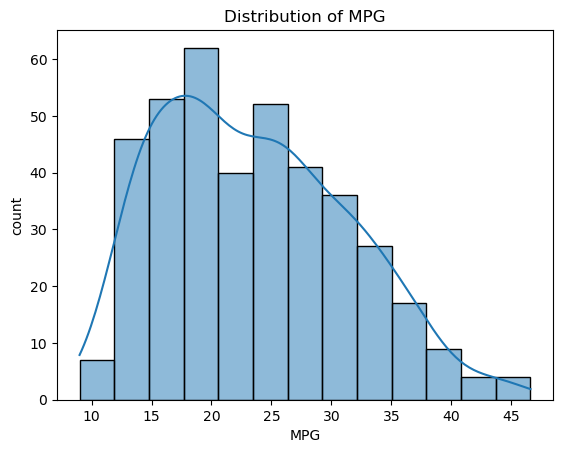

In [115]:
sns.histplot(data=df,x="mpg",kde=True)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("count")

#what is the range of where most of the car's mileage lie?
# most of the car mileage lies between 15-22 miles per gallon.

In [117]:
df["mpg"].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

# How many cars are there from each origin?



/var/folders/zr/yf7yczb95nv_tkd0pg7hxjww0000gn/T/ipykernel_1111/762758824.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y="origin",width=0.4,palette="rocket")


Text(0, 0.5, 'Count')

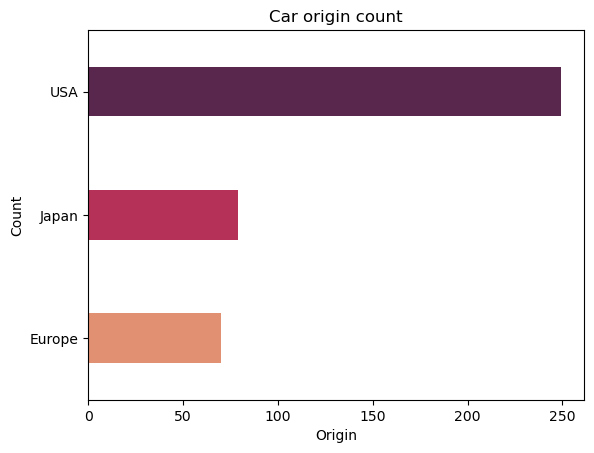

In [120]:
sns.countplot(data=df,y="origin",width=0.4,palette="rocket")
plt.title("Car origin count")
plt.xlabel("Origin")
plt.ylabel("Count")


# 3. What is proportion of cars are from each origin (USA, Europe,Japan)?

In [123]:
car_count=df["origin"].value_counts()
car_count

origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

In [125]:
car_count.index

Index(['USA', 'Japan', 'Europe'], dtype='object', name='origin')

([<matplotlib.patches.Wedge at 0x16b4ec2f0>,
 [Text(-0.45756185065750954, 1.0985158864681364, 'USA'),
  Text(-0.17293561388226758, -1.0863209808574827, 'Japan'),
  Text(0.93631267527795, -0.5773374871891209, 'Europe')],
 [Text(-0.2653089722299845, 0.6369545896327847, '62.56%'),
  Text(-0.09432851666305503, -0.5925387168313542, '19.85%'),
  Text(0.5107160046970636, -0.3149113566486114, '17.59%')])

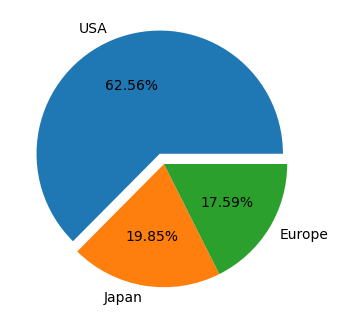

In [127]:
plt.figure(figsize=(5,4))
plt.pie(car_count,
        labels=car_count.index,
        autopct="%0.2f%%",
        explode=[0.09,0,0])
        

# 4. What percentage of cars belongs to each cylinder category?

In [130]:
cylinder_count=df["cylinders"].value_counts()
cylinder_count

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x16be5ab40>,
 [Text(-0.04340268967550522, 1.0991433967089699, '4'),
  Text(-0.6906767581881664, -0.8561341108136535, '8'),
  Text(1.1446869214746362, -1.1178961721935181, '6'),
  Text(1.0965749247684011, -0.08673773324900445, '3'),
  Text(1.0996915986507076, -0.026045879847893992, '5')],
 [Text(-0.023674194368457392, 0.5995327618412563, '51.26%'),
  Text(-0.37673277719354525, -0.4669822422619928, '25.88%'),
  Text(0.7869722585138124, -0.7685536183830437, '21.11%'),
  Text(0.5981317771464005, -0.04731149086309333, '1.01%'),
  Text(0.5998317810822041, -0.014206843553396721, '0.75%')])

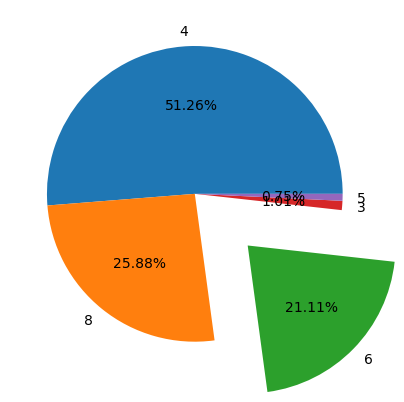

In [132]:
plt.pie(cylinder_count,labels=cylinder_count.index,autopct="%0.2f%%",explode=[0,0,0.5,0,0])

# Data Cleaning:

In [135]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin           object
car name         object
dtype: object

In [137]:
df["horsepower"]=df["horsepower"].astype("int64")

#the conversion of thos column into numeric type is not possible because it contains some entries like "?" which cannot be directly
#coverted into numbers

ValueError: invalid literal for int() with base 10: '?'

In [139]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,USA,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,USA,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,Europe,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,USA,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,USA,ford ranger


In [141]:
"7879898".isdigit()

True

In [143]:
hp_is_digit=pd.DataFrame(df["horsepower"].str.isdigit())   # identifying all the rows which contain digit type of string

In [145]:
df[hp_is_digit["horsepower"]==False]  #identifying all the rows which contain ? type of string

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,USA,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,USA,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,Europe,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,USA,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,Europe,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,USA,amc concord dl


In [147]:
df["horsepower"]=df["horsepower"].replace("?",np.nan)  # replacing it will NAN

In [149]:
df[hp_is_digit["horsepower"]==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,USA,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,USA,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,Europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,USA,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,Europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,USA,amc concord dl


In [151]:
df["horsepower"]=df["horsepower"].astype("float64")  #conversion is possible.

In [153]:
# perform the data cleaning:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [155]:
df["horsepower"].describe()

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

In [157]:
df["horsepower"]=df["horsepower"].fillna(df["horsepower"].median())

In [159]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [78]:
df.duplicated().sum()

0

# 5. What is the relationship between horsepower and weight of car?

In [161]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin           object
car name         object
dtype: object

In [173]:
df.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137
model year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000


In [175]:
df[["horsepower","weight"]].corr()

,horsepower,weight
horsepower,1.000000,0.862442
weight,0.862442,1.000000


if horsepower of the car increase it has direct impact on the weight of car as well.

Text(0.5, 1.0, 'Weight Vs Horsepower')

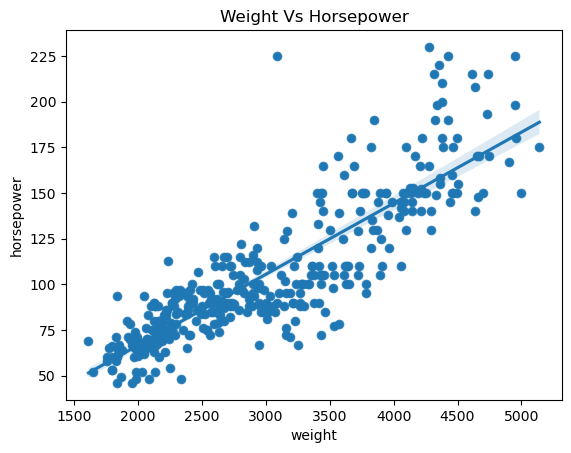

In [186]:
sns.scatterplot(data=df,x="weight",y="horsepower")
sns.regplot(data=df,x="weight",y="horsepower")
plt.title("Weight Vs Horsepower")

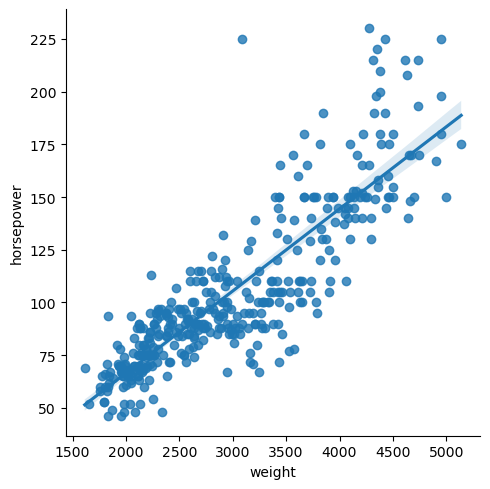

In [184]:
#sns.scatterplot(data=df,x="weight",y="horsepower")
sns.lmplot(data=df,x="weight",y="horsepower")

# 6. How does MPG vary across different number of cylinders?

In [211]:
x=df[df["cylinders"]==6]
x

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
15,22.0,6,198.0,95.0,2833,15.5,70,USA,plymouth duster
16,18.0,6,199.0,97.0,2774,15.5,70,USA,amc hornet
17,21.0,6,200.0,85.0,2587,16.0,70,USA,ford maverick
24,21.0,6,199.0,90.0,2648,15.0,70,USA,amc gremlin
33,19.0,6,232.0,100.0,2634,13.0,71,USA,amc gremlin
...,...,...,...,...,...,...,...,...,...
365,20.2,6,200.0,88.0,3060,17.1,81,USA,ford granada gl
366,17.6,6,225.0,85.0,3465,16.6,81,USA,chrysler lebaron salon
386,25.0,6,181.0,110.0,2945,16.4,82,USA,buick century limited
387,38.0,6,262.0,85.0,3015,17.0,82,USA,oldsmobile cutlass ciera (diesel)


<Axes: xlabel='mpg', ylabel='Count'>

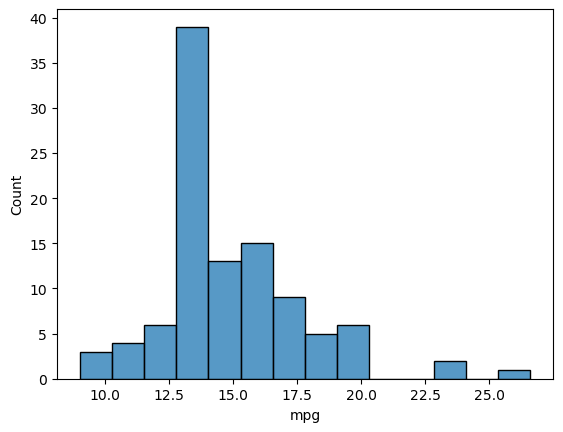

In [203]:
sns.histplot(data=x["mpg"])

<Axes: xlabel='cylinders', ylabel='mpg'>

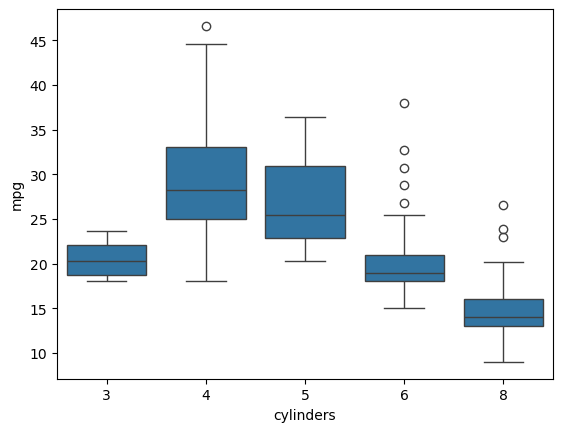

In [207]:
sns.boxplot(data=df,x="cylinders",y="mpg")

4-5 cylinders car are more fuel efficient (heigher mpg) than 8-cylinder cars.

<Axes: xlabel='cylinders', ylabel='horsepower'>

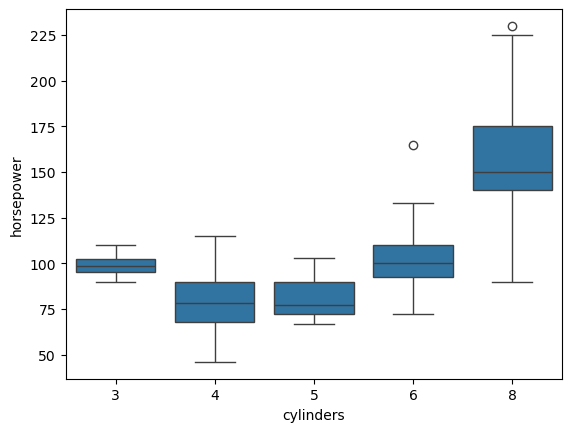

In [214]:
# how horse power may vary across different count of cylinders.
sns.boxplot(data=df,x="cylinders",y="horsepower")

8 cylinder cars have more powerful engines (high horse power) than 4-5 cylinder cars.

# How does horse power vary by origin?

<Axes: xlabel='horsepower', ylabel='origin'>

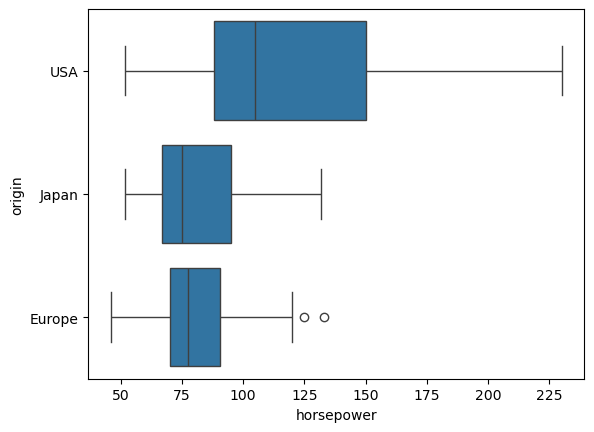

In [220]:
sns.boxplot(data=df,x="horsepower",y="origin")

# What is the distribution of displacement in the dataset?


<Axes: xlabel='displacement', ylabel='Count'>

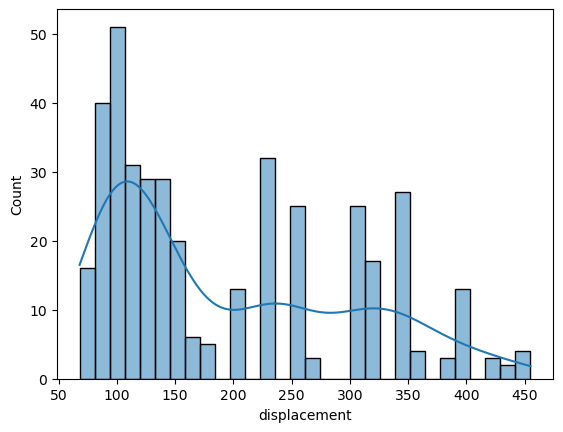

In [229]:
sns.histplot(data=df,x="displacement",kde=True,bins=30)

In [231]:
df["displacement"].describe()

count    398.000000
mean     193.425879
std      104.269838
min       68.000000
25%      104.250000
50%      148.500000
75%      262.000000
max      455.000000
Name: displacement, dtype: float64

most of the cars have engine displacement <150 cc.

# how does the weight affect the mpg.

In [235]:
df[["mpg","weight"]].corr()

,mpg,weight
mpg,1.000000,-0.831741
weight,-0.831741,1.000000


<Axes: xlabel='weight', ylabel='mpg'>

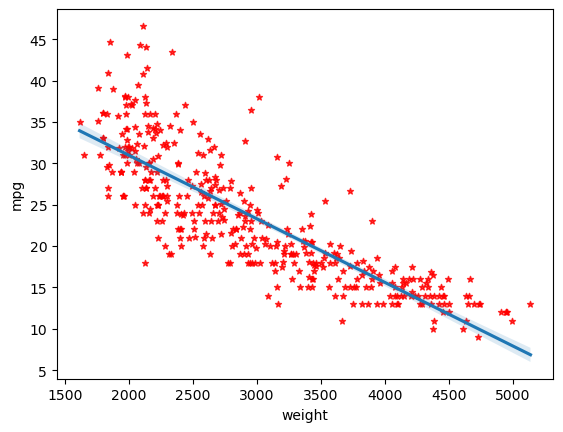

In [251]:
sns.regplot(data=df,x="weight",y="mpg",marker="*",scatter_kws={"color":"r","s":20})

In [ ]:
# what is the relationship between mpg and horse power?
# how does the weight of cars vary by their origin?
# what relationship can be inferred between mpg,horsepower and weight?

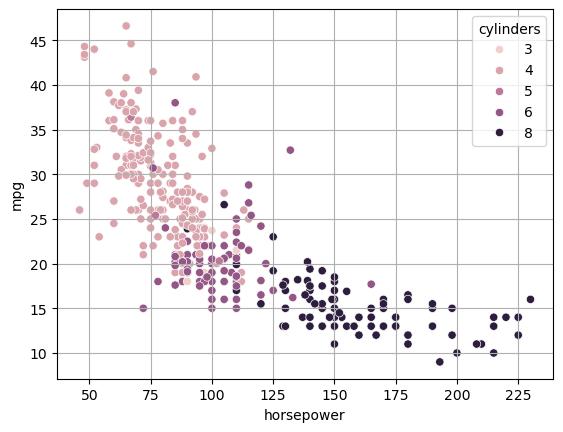

In [267]:
#how does the relationship between horsepower and mpg vary accross diff cylinder categories.
sns.scatterplot(data=df,x="horsepower",y="mpg",hue="cylinders")
plt.grid()